## **Image Classification Model - T2 Regularized CNN**

### **Purpose**

The purpose of this notebook is to train and evaluate an improved custom CNN model for the Lexical Bridge Photo Mission feature. The model classifies uploaded images into one of nine target object classes, such as cat, dog, bird, flower, fruit, vegetable, car, bicycle, and shoe.

This trial keeps the same training augmentation used in the previous experiment, including random horizontal flipping, random rotation, and color jittering. The main improvement is the addition of regularization and parameter-reduction techniques, including Batch Normalization, Global Average Pooling, and Dropout. These changes are used to reduce overfitting and improve generalization while keeping the model trained from scratch.



### **Structure**
1. Upload and extract the dataset ZIP file
2. Import libraries and set training configuration
3. Prepare image transforms and data loaders with training augmentation
4. Define and summarize the regularized CNN model
5. Set the loss function and optimizer
6. Define training and evaluation functions
7. Train the regularized CNN model
8. Visualize training history
9. Evaluate the best validation checkpoint on the test set
10. Collect test predictions and analyze per-class accuracy
11. Generate the confusion matrix and classification report

## 1. Upload and Extract Dataset ZIP File

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

ZIP_PATH = '/content/drive/MyDrive/LB_dataset.zip'
DATASET_DIR = Path('/content/dataset')

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

shutil.unpack_archive(ZIP_PATH, str(DATASET_DIR))
print('Dataset ZIP file extracted.')

!ls /content/dataset

Mounted at /content/drive
Dataset ZIP file extracted.
test  train  val


## 2. Import Libraries and Set Training Configuration

In [ ]:
!pip install -q torchinfo

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Training hyperparameters
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_EPOCHS = 30
LR = 1e-3
NUM_WORKERS = 0

# ImageNet normalization statistics, commonly used for natural image datasets
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Map detailed classes into broader game categories
CATEGORY_MAP = {
    'cat': 'animal',     'dog': 'animal',     'bird': 'animal',
    'flower': 'nature',  'fruit': 'nature',   'vegetable': 'nature',
    'car': 'daily_life', 'bicycle': 'daily_life', 'shoe': 'daily_life',
}

# Model checkpoint save paths
MODEL_SAVE_PATH = '/content/best_model.pth'
DRIVE_SAVE_PATH = '/content/drive/MyDrive/dyslexiread_best_model.pth'

Device: cuda
GPU: Tesla T4


## 3. Prepare Image Transforms and Data Loaders

In [ ]:
# Basic image transform with data augmentation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# No data augmentation for the val / test
basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# Load image folders for train, validation, and test sets
train_ds = datasets.ImageFolder(str(DATASET_DIR / 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATASET_DIR / 'val'),   transform=basic_tf)
test_ds  = datasets.ImageFolder(str(DATASET_DIR / 'test'),  transform=basic_tf)
CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# Create data loaders for mini-batch training and evaluation
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Classes (9): ['bicycle', 'bird', 'car', 'cat', 'dog', 'flower', 'fruit', 'shoe', 'vegetable']
Train: 6219 | Val: 1333 | Test: 1333


## 4. Define CNN Model with Regularization

In [ ]:
class BaselineCNN(nn.Module):
    """
    Improved CNN baseline with regularization techniques

    Architecture
    - Four convolutional blocks: Conv2d -> BatchNorm -> ReLU -> MaxPool
    - Global Average Pooling to reduce FC parameters and prevent overfitting
    - Fully connected classifier with Dropout regularization
    """
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: input channels 3 -> output channels 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),       # Stabilize training and improve generalization
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # Global Average Pooling reduces each feature map to a single value,
        # significantly reducing the number of parameters in the classifier
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Final classification layers with dropout for regularization
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),                  # Strong dropout before first FC layer
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),                  # Lighter dropout before output layer
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
# Count total and trainable model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
# Display a detailed model summary
summary(
    model,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
)

Total parameters:     423,433
Trainable parameters: 423,433


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BaselineCNN                              [64, 3, 128, 128]         [64, 9]                   --                        True
├─Sequential: 1-1                        [64, 3, 128, 128]         [64, 256, 8, 8]           --                        True
│    └─Conv2d: 2-1                       [64, 3, 128, 128]         [64, 32, 128, 128]        896                       True
│    └─BatchNorm2d: 2-2                  [64, 32, 128, 128]        [64, 32, 128, 128]        64                        True
│    └─ReLU: 2-3                         [64, 32, 128, 128]        [64, 32, 128, 128]        --                        --
│    └─MaxPool2d: 2-4                    [64, 32, 128, 128]        [64, 32, 64, 64]          --                        --
│    └─Conv2d: 2-5                       [64, 32, 64, 64]          [64, 64, 64, 64]          18,496                    True
│    └─

## 5. Set Loss Function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)
print('Loss function: CrossEntropyLoss')
print(f'Optimizer: Adam (lr={LR})')

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


## 6. Define Training and Evaluation Functions

In [ ]:
def train(model, loader, criterion, optimizer, device):
    # Set the model to training mode
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # Forward pass, loss calculation, and parameter update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Accumulate loss and accuracy
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    # Set the model to evaluation mode
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Forward pass only, without gradient calculation
            outputs = model(images)
            loss = criterion(outputs, labels)
            # Accumulate loss and accuracy
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

## 7. Train the CNN Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

# Train the model for the defined number of epochs
for epoch in range(NUM_EPOCHS):
    # Run one training epoch and evaluate on the validation set
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Store training history for later visualization
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save the model when validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'class_names': CLASS_NAMES,
        }, MODEL_SAVE_PATH)
    print(
        f'Epoch {epoch + 1:2d}/{NUM_EPOCHS} | '
        f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
        f'val loss {val_loss:.4f} acc {val_acc:.4f}'
    )
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch  1/30 | train loss 1.8639 acc 0.2885 | val loss 1.6880 acc 0.3706
Epoch  2/30 | train loss 1.7242 acc 0.3493 | val loss 1.7477 acc 0.3338
Epoch  3/30 | train loss 1.6849 acc 0.3706 | val loss 1.6583 acc 0.3818
Epoch  4/30 | train loss 1.6340 acc 0.3862 | val loss 1.5456 acc 0.4321
Epoch  5/30 | train loss 1.6051 acc 0.3946 | val loss 1.5192 acc 0.4359
Epoch  6/30 | train loss 1.5956 acc 0.4057 | val loss 1.4829 acc 0.4434
Epoch  7/30 | train loss 1.5604 acc 0.4124 | val loss 1.4957 acc 0.4606
Epoch  8/30 | train loss 1.5315 acc 0.4247 | val loss 1.4845 acc 0.4389
Epoch  9/30 | train loss 1.5045 acc 0.4404 | val loss 1.5319 acc 0.4299
Epoch 10/30 | train loss 1.4886 acc 0.4403 | val loss 1.4830 acc 0.4329
Epoch 11/30 | train loss 1.4679 acc 0.4512 | val loss 1.4716 acc 0.4786
Epoch 12/30 | train loss 1.4452 acc 0.4543 | val loss 1.4495 acc 0.4621
Epoch 13/30 | train loss 1.4305 acc 0.4723 | val loss 1.3454 acc 0.5004
Epoch 14/30 | train loss 1.4207 acc 0.4715 | val loss 1.3271 acc

## 8. Visualize Training History

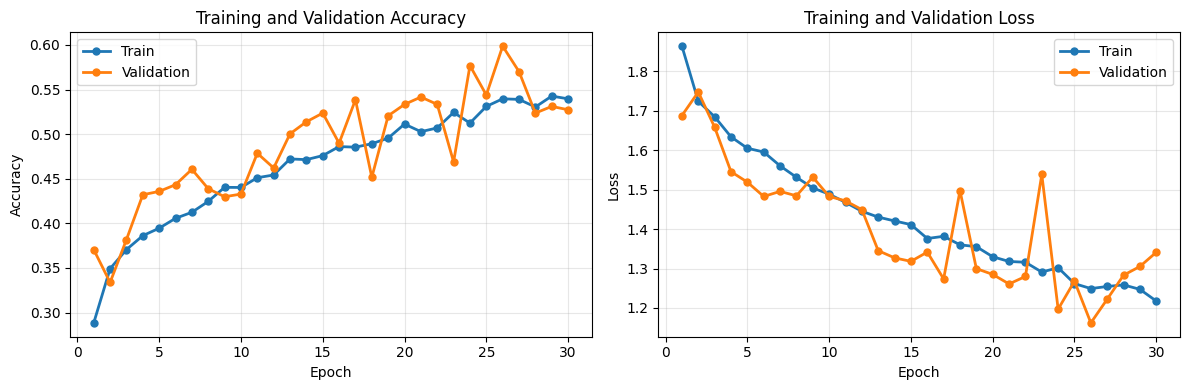

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

# Plot training and validation accuracy
axes[0].plot(epochs_range, history['train_acc'], label='Train', linewidth=2, marker='o', markersize=5)
axes[0].plot(epochs_range, history['val_acc'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot training and validation loss
axes[1].plot(epochs_range, history['train_loss'], label='Train', linewidth=2, marker='o', markersize=5)
axes[1].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate the Best Model on the Test Set

In [ ]:
# Load the best model checkpoint saved during validation
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} (val acc {checkpoint["val_acc"]:.4f})')

# Evaluate the best model on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest loss: {test_loss:.4f}')
print(f'Test accuracy (class-level): {test_acc:.4f}')

Loaded best model from epoch 26 (val acc 0.5986)

Test loss: 1.1962
Test accuracy (class-level): 0.5626


## 10. Analyze Accuracy Per Class

In [ ]:
def collect_predictions(model, loader, device):
    # Set the model to evaluation mode
    model.eval()
    all_preds, all_labels = [], []

    # Collect predicted labels and true labels from the test set
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# Collect predicted labels and true labels from the test set
y_pred, y_true = collect_predictions(model, test_loader, device)
print('Accuracy per class')

# Calculate accuracy for each class separately
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        print(f'  {cls:<10s} {acc:.4f}  ({mask.sum()} samples)')

Accuracy per class
  bicycle    0.7067  (150 samples)
  bird       0.5467  (150 samples)
  car        0.7000  (150 samples)
  cat        0.4600  (150 samples)
  dog        0.4400  (150 samples)
  flower     0.7533  (150 samples)
  fruit      0.4200  (150 samples)
  shoe       0.4667  (150 samples)
  vegetable  0.5714  (133 samples)


## 11. Confusion Matrix and Classification Report

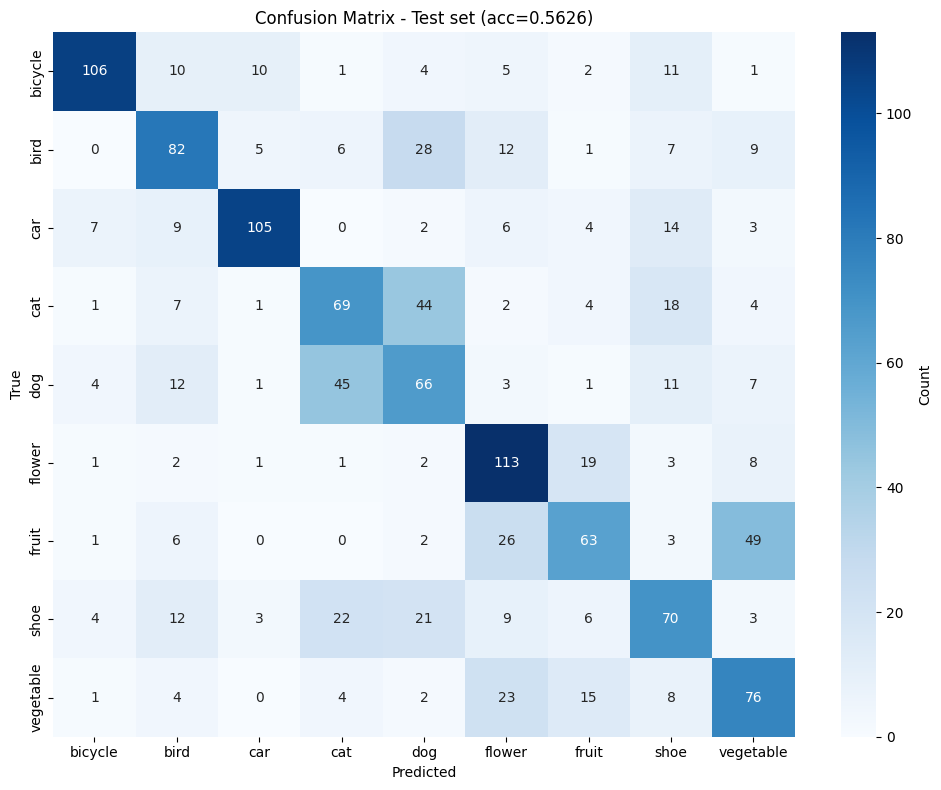


Classification report
              precision    recall  f1-score   support

     bicycle     0.8480    0.7067    0.7709       150
        bird     0.5694    0.5467    0.5578       150
         car     0.8333    0.7000    0.7609       150
         cat     0.4662    0.4600    0.4631       150
         dog     0.3860    0.4400    0.4112       150
      flower     0.5678    0.7533    0.6476       150
       fruit     0.5478    0.4200    0.4755       150
        shoe     0.4828    0.4667    0.4746       150
   vegetable     0.4750    0.5714    0.5188       133

    accuracy                         0.5626      1333
   macro avg     0.5752    0.5628    0.5645      1333
weighted avg     0.5764    0.5626    0.5651      1333



In [ ]:
# Compute the confusion matrix using true and predicted labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

# Visualize how often each true class was predicted as each class
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Test set (acc={test_acc:.4f})')
plt.tight_layout()
plt.show()

# Print precision, recall, and F1-score for each class
print('\nClassification report')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

In [ ]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>